**DSBDAL Assignment No:2**

*Import the pandas and numpy libraries for the check missing value*

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv(r"Assignment2.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Assignment2.csv'

In [ ]:
df.head(3)

In [ ]:
df.isnull()

**check the Specific column missing value**

In [ ]:
serise= pd.isnull(df["math score"])
df[serise]

In [ ]:
df.notnull()

In [ ]:
serise1 = pd.notnull(df["math score"])
df[serise1]

**Lable Encoding using sklearn**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
newdf = df
df

**Filling missing value in dataset using the fillna**

In [ ]:
missing_value = ["Na","na"]
df = pd.read_csv("Assignment2.csv", na_values = missing_value )
df

**Filling missing value with a single value**

In [ ]:
ndf = df 
ndf.fillna(0)

**filling missing value in dataset**

In [ ]:
m_v = df["math score"].mean()
df["math score"].fillna(value= m_v , inplace= True)
df

In [ ]:
ndf.replace(to_replace = np.nan , value = -99)

In [ ]:
ndf.dropna()

In [ ]:
 ndf.dropna(how = 'all')

In [ ]:
ndf.dropna(axis = 1)

In [ ]:
new_data = ndf.dropna(axis = 0 , how = 'any')

In [ ]:
new_data

***Identification and handling of Outliers***

In [ ]:
import pandas as pd 
import numpy as np 
df = pd.read_csv("archive/outliers.csv")
df

In [ ]:
df.columns

**Boxplots**

In [ ]:
col = ['math score', 'reading score', 'writing score', 'placement score']
df.boxplot(col)

In [ ]:
print(np.where(df['math score']>90))

***Detecting Outliers  Using Scatterploat***

In [ ]:
import matplotlib.pyplot as plt
df = pd.read_csv("archive/outliers.csv")
df

In [ ]:
fig , ax = plt.subplots(figsize = (18,10))
ax.scatter(df['placement score'] , df['placement offer count'])
plt.show()

**detecting outliers using the Z-score**

In [ ]:
import numpy as np
from scipy import stats

z = np.abs(stats.zscore(df['math score']))

threshold = 0.18

sample_outliers = np.where(z > threshold)

print(sample_outliers)

**Inter Qunatile Range (IQR)**

In [ ]:
sorted_rscore= sorted(df['reading score'])
sorted_rscore

In [ ]:
q1 = np.percentile(sorted_rscore, 25)
q3 = np.percentile(sorted_rscore, 75)
print(q1,q3)

In [ ]:
IQR = q3-q1


In [ ]:
lwr_bound = q1-(1.5*IQR)
upr_bound = q3+(1.5*IQR)
print(lwr_bound, upr_bound)

In [ ]:
r_outliers = []
for i in sorted_rscore:
 if (i<lwr_bound or i>upr_bound):
  r_outliers.append(i)
print(r_outliers)

**Handling of Outliers:**

- Trimming/removing the outlier:



In [ ]:
new_df=df
for i in sample_outliers:
 new_df.drop(i,inplace=True)
new_df

- Quantile based flooring and capping

In [ ]:
df=pd.read_csv("archive/outliers.csv")
df_stud=df
ninetieth_percentile = np.percentile(df_stud['math score'], 90)
b = np.where(df_stud['math score']>ninetieth_percentile,ninetieth_percentile, df_stud['math score'])
print("New array:",b)

In [ ]:
df_stud.insert(1,"m score",b,True)
df_stud


- Mean/Median imputation:

In [ ]:
col = ['reading score']
df.boxplot(col)

In [ ]:
median=np.median(sorted_rscore)
median

In [ ]:
refined_df=df
refined_df['reading score'] = np.where(refined_df['reading score'] >upr_bound, median,refined_df['reading score'])
refined_df

**Lower bound  outliers using the median**

In [ ]:
refined_df['reading score'] = np.where(refined_df['reading score'] <lwr_bound, median,refined_df['reading score'])


In [ ]:
col = ['reading score']
refined_df.boxplot(col)

**Data Transformation**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("archive/outliers.csv")
df.head()


,math score,reading score,writing score,placement score,placement offer count,club join year
0,80,68,70,89,3,2019
1,71,61,85,91,3,2019
2,79,16,87,77,2,2018
3,61,77,74,76,2,2020
4,78,71,67,90,3,2019


In [8]:
df.skew(numeric_only=True)


math score               2.879976
reading score           -1.118335
writing score           -2.551347
placement score          0.704166
placement offer count   -0.705767
club join year           0.395053
dtype: float64

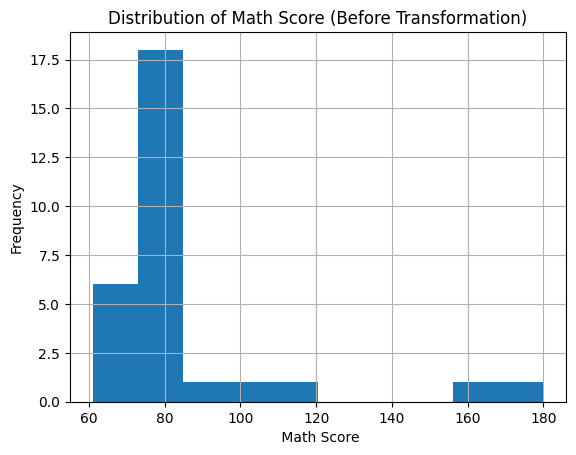

In [12]:
df['math score'].hist(bins=10)
plt.xlabel(" Math Score")
plt.ylabel("Frequency")
plt.title("Distribution of Math Score (Before Transformation)")
plt.show()


**Apply Log Transformation**

In [13]:
df['log_math_Score'] = np.log10(df['math score'])


In [14]:
df['log_math_Score'].skew()



np.float64(2.416925142781312)

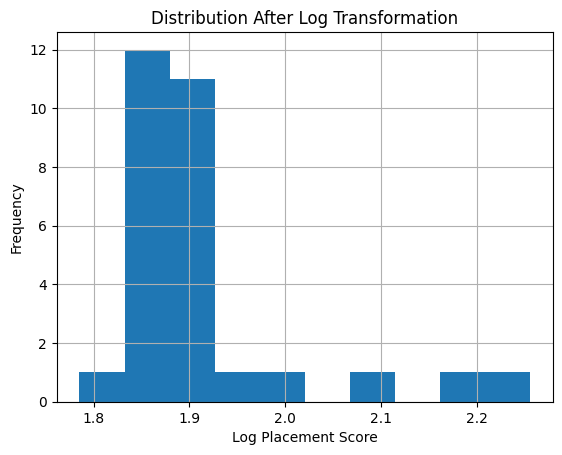

In [15]:
df['log_math_Score'].hist(bins=10)
plt.xlabel("Log math Score")
plt.ylabel("Frequency")
plt.title("Distribution After Log Transformation")
plt.show()


**Visualize Reading Score Distribution (Before Transformation)**

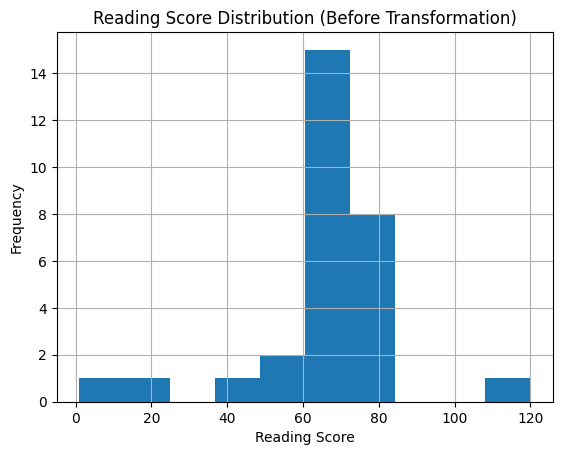

In [25]:
df['reading score'].hist(bins=10)
plt.xlabel("Reading Score")
plt.ylabel("Frequency")
plt.title("Reading Score Distribution (Before Transformation)")
plt.show()


**Square Root Transformation**

In [26]:
df['sqrt_Reading_Score'] = np.sqrt(df['reading score'])
df['sqrt_Reading_Score'].skew()



np.float64(-2.838375897620973)

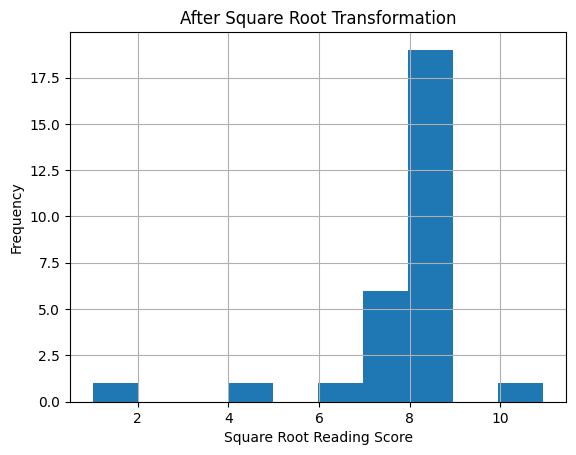

In [27]:
df['sqrt_Reading_Score'].hist(bins=10)
plt.xlabel("Square Root Reading Score")
plt.ylabel("Frequency")
plt.title("After Square Root Transformation")
plt.show()
